# ICO Fundraising Success Prediction

## Data Exploration

In this notebook, we perform an initial exploration of the ICO dataset to understand its structure, identify missing values, inspect feature types, and prepare the data for preprocessing and model development.

In [38]:
# Import required libraries

import pandas as pd
import numpy as np

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [39]:
# Load the dataset

df = pd.read_csv("../data/raw/LUBS5990M_courseworkData_202526.csv")

# Display the first five rows
df.head()

,country,ico_start,ico_end,price_usd,goal,distributed_in_ico,sold_tokens,token_for_sale,whitelist,kyc,bonus,mvp,pre_ico_start,pre_ico_end,pre_ico_price_usd,link_white_paper,linkedin_link,github_link,website,rating,teamsize,ERC20
0,India,10-08-2020,31-12-2020,0.01,1,0.5,100000000.0,500000000.0,YES,Y,1,Available,NaN,NaN,0.005,NaN,https://www.linkedin.com/company/bitfinex-limi...,NaN,NaN,4.0,NaN,1
1,Cyprus,01-08-2020,31-12-2020,0.10,0,0.6,NaN,84000000.0,n,TRUE,no,Yes,22-07-2019,31-10-2019,NaN,https://www.tycoon.io/whitepaper.pdf,https://www.linkedin.com/company/tycoonio/about/,https://www.github.com/tycoon?tab=repositories,https://www.tycoon.io?utm_source=icobench,4.8,14.0,1
2,UK,01-03-2019,31-12-2020,0.14,1,0.5,NaN,75000000.0,N,no,Y,AVAILABLE,15-12-2018,15-01-2019,NaN,https://mindsync.ai/docs/whitepaper.pdf,https://www.linkedin.com/company/mindsync/,NaN,NaN,4.5,14.0,TRUE
3,UK,25-06-2020,31-01-2021,0.10,0,0.5,NaN,500000000.0,y,yes,yes,Yes,NaN,NaN,0.100,https://cdn.pointpay.io/WhitePaper__en.pdf?cac...,https://www.linkedin.com/company/pointpay/about/,NaN,NaN,4.7,43.0,T
4,Seychelles,NaN,NaN,0.06,0,0.4,NaN,400000000.0,y,1,1,yes,NaN,NaN,0.030,https://lohncontrol.com/down/LOHN-white-paper-...,https://www.linkedin.com/showcase/lohncontrol,https://www.github.com/lohn7?tab=repositories,https://lohncontrol.com?utm_source=icobench,4.4,16.0,1


In [40]:
# Dataset dimensions

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 5828
Number of columns: 22


In [41]:
# Display all column names

df.columns

Index(['country', 'ico_start', 'ico_end', 'price_usd', 'goal',
       'distributed_in_ico', 'sold_tokens', 'token_for_sale', 'whitelist',
       'kyc', 'bonus', 'mvp', 'pre_ico_start', 'pre_ico_end',
       'pre_ico_price_usd', 'link_white_paper', 'linkedin_link', 'github_link',
       'website', 'rating', 'teamsize', 'ERC20'],
      dtype='str')

In [42]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5828 entries, 0 to 5827
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             5828 non-null   str    
 1   ico_start           5244 non-null   str    
 2   ico_end             5111 non-null   str    
 3   price_usd           5374 non-null   float64
 4   goal                5828 non-null   int64  
 5   distributed_in_ico  4436 non-null   float64
 6   sold_tokens         175 non-null    float64
 7   token_for_sale      4678 non-null   float64
 8   whitelist           3551 non-null   str    
 9   kyc                 5828 non-null   str    
 10  bonus               5828 non-null   str    
 11  mvp                 1188 non-null   str    
 12  pre_ico_start       2553 non-null   str    
 13  pre_ico_end         2543 non-null   str    
 14  pre_ico_price_usd   1497 non-null   float64
 15  link_white_paper    5290 non-null   str    
 16  linkedin_link    

In [43]:
# Statistical summary of numerical columns

df.describe()

,price_usd,goal,distributed_in_ico,sold_tokens,token_for_sale,pre_ico_price_usd,rating,teamsize
count,5.374000e+03,5828.000000,4436.000000,1.750000e+02,4.678000e+03,1.497000e+03,5178.000000,4213.000000
mean,2.283607e+02,0.341627,25.403615,1.015443e+14,5.969122e+12,1.141152e+04,2.936501,10.783052
std,1.203153e+04,0.474296,122.532263,1.044824e+15,3.376997e+14,4.318172e+05,0.761720,7.285419
min,3.170000e-16,0.000000,0.000000,1.000000e+00,2.000000e+00,2.000000e-05,0.200000,1.000000
25%,4.400000e-02,0.000000,0.400000,3.075000e+06,4.000000e+07,4.000000e-02,2.400000,5.000000
50%,1.500000e-01,0.000000,0.560000,1.658860e+07,1.500000e+08,1.000000e-01,2.900000,9.000000
75%,7.126895e-01,1.000000,0.700000,1.366543e+08,5.100000e+08,4.400000e-01,3.500000,15.000000
max,8.284860e+05,1.000000,995.000000,1.300000e+16,2.260000e+16,1.670525e+07,5.000000,66.000000


In [44]:
# Check missing values

missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage.round(2)
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
sold_tokens,5653,97.00
mvp,4640,79.62
pre_ico_price_usd,4331,74.31
pre_ico_end,3285,56.37
pre_ico_start,3275,56.19
github_link,3226,55.35
whitelist,2277,39.07
linkedin_link,1907,32.72
teamsize,1615,27.71
distributed_in_ico,1392,23.88


In [45]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [46]:
# Count the target variable

df["goal"].value_counts()

goal
0    3837
1    1991
Name: count, dtype: int64

In [47]:
# Percentage distribution

df["goal"].value_counts(normalize=True) * 100

goal
0    65.837337
1    34.162663
Name: proportion, dtype: float64

In [48]:
import matplotlib.pyplot as plt

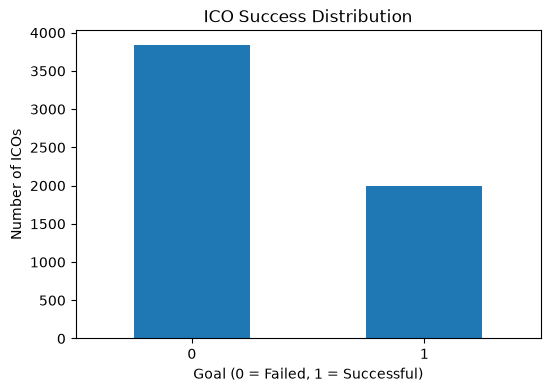

In [49]:
# Bar chart of target variable

plt.figure(figsize=(6,4))

df["goal"].value_counts().sort_index().plot(kind="bar")

plt.title("ICO Success Distribution")
plt.xlabel("Goal (0 = Failed, 1 = Successful)")
plt.ylabel("Number of ICOs")
plt.xticks(rotation=0)

plt.show()

In [50]:
# Average rating by ICO success

df.groupby("goal")["rating"].mean()

goal
0    2.804982
1    3.182060
Name: rating, dtype: float64

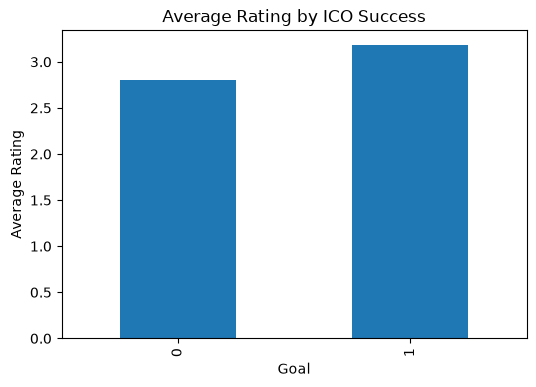

In [51]:
plt.figure(figsize=(6,4))

df.groupby("goal")["rating"].mean().plot(kind="bar")

plt.title("Average Rating by ICO Success")
plt.xlabel("Goal")
plt.ylabel("Average Rating")

plt.show()

In [52]:
df.groupby("goal")["price_usd"].mean()

goal
0    345.867295
1     16.628193
Name: price_usd, dtype: float64

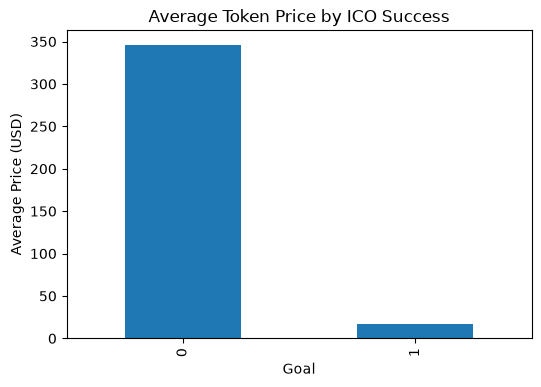

In [53]:
plt.figure(figsize=(6,4))

df.groupby("goal")["price_usd"].mean().plot(kind="bar")

plt.title("Average Token Price by ICO Success")
plt.xlabel("Goal")
plt.ylabel("Average Price (USD)")

plt.show()

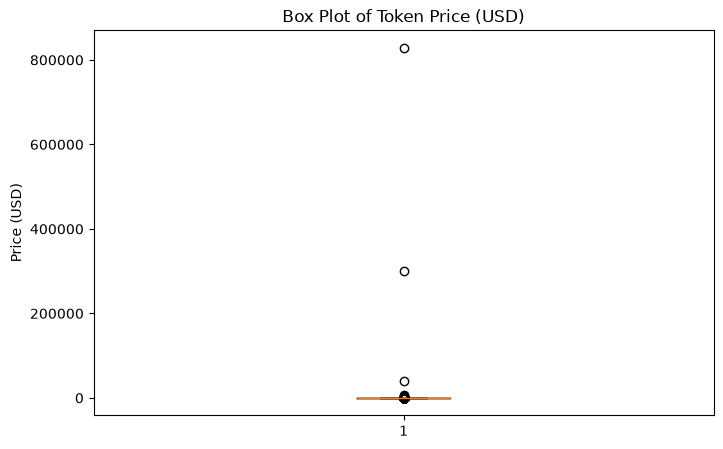

In [54]:
plt.figure(figsize=(8,5))

plt.boxplot(df["price_usd"].dropna())

plt.title("Box Plot of Token Price (USD)")
plt.ylabel("Price (USD)")

plt.show()

In [55]:
df["price_usd"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25      0.04400
0.50      0.15000
0.75      0.71269
0.90      1.57280
0.95      6.00000
0.99    232.58386
Name: price_usd, dtype: float64

In [56]:
pd.crosstab(df["kyc"], df["goal"])

goal,0,1
kyc,,
0,608,330
1,467,253
FALSE,629,330
N,336,152
No,322,150
TRUE,470,238
Y,213,114
Yes,229,110
no,331,196


In [57]:
pd.crosstab(df["bonus"], df["goal"])

goal,0,1
bonus,,
0,1395,827
1,127,6
N,682,359
No,729,397
Y,71,4
Yes,66,1
no,705,394
yes,62,3


In [58]:
pd.crosstab(df["ERC20"], df["goal"])

goal,0,1
ERC20,,
0,162,76
1,979,488
F,85,31
FALSE,220,103
T,452,261
TRUE,1452,844


In [59]:
pd.crosstab(df["kyc"], df["goal"], normalize="index") * 100

goal,0,1
kyc,,
0,64.818763,35.181237
1,64.861111,35.138889
FALSE,65.589155,34.410845
N,68.852459,31.147541
No,68.220339,31.779661
TRUE,66.384181,33.615819
Y,65.137615,34.862385
Yes,67.551622,32.448378
no,62.808349,37.191651


In [60]:
# Create a copy of the dataset

df_clean = df.copy()

In [61]:
# Standardize KYC values

df_clean["kyc"] = df_clean["kyc"].replace({
    "1": "Yes",
    "0": "No",
    1: "Yes",
    0: "No",
    "TRUE": "Yes",
    "FALSE": "No",
    "Y": "Yes",
    "N": "No",
    "yes": "Yes",
    "no": "No"
})
df_clean["kyc"].value_counts()

kyc
No     3384
Yes    2444
Name: count, dtype: int64

In [62]:
df_clean["bonus"] = df_clean["bonus"].replace({
    "1": "Yes",
    "0": "No",
    1: "Yes",
    0: "No",
    "TRUE": "Yes",
    "FALSE": "No",
    "Y": "Yes",
    "N": "No",
    "yes": "Yes",
    "no": "No"
})

df_clean["bonus"].value_counts()

bonus
No     5488
Yes     340
Name: count, dtype: int64

In [63]:
df_clean["ERC20"] = df_clean["ERC20"].replace({
    "1": "Yes",
    "0": "No",
    1: "Yes",
    0: "No",
    "TRUE": "Yes",
    "FALSE": "No",
    "T": "Yes",
    "F": "No"
})

df_clean["ERC20"].value_counts()

ERC20
Yes    4476
No      677
Name: count, dtype: int64

In [65]:
# Drop columns with more than 50% missing values

columns_to_drop = [
    "sold_tokens",
    "mvp",
    "pre_ico_price_usd",
    "pre_ico_end",
    "pre_ico_start",
    "github_link"
]

df_clean.drop(columns=columns_to_drop, inplace=True)

In [66]:
print(df_clean.shape)
df_clean.columns

(5828, 16)


Index(['country', 'ico_start', 'ico_end', 'price_usd', 'goal',
       'distributed_in_ico', 'token_for_sale', 'whitelist', 'kyc', 'bonus',
       'link_white_paper', 'linkedin_link', 'website', 'rating', 'teamsize',
       'ERC20'],
      dtype='str')

In [67]:
df_clean.isnull().sum()

country                  0
ico_start              584
ico_end                717
price_usd              454
goal                     0
distributed_in_ico    1392
token_for_sale        1150
whitelist             2277
kyc                      0
bonus                    0
link_white_paper       538
linkedin_link         1907
website                702
rating                 650
teamsize              1615
ERC20                  675
dtype: int64

In [70]:
# Fill missing values in numerical columns with median

numerical_cols = [
    "price_usd",
    "distributed_in_ico",
    "token_for_sale",
    "rating",
    "teamsize"
]

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [71]:
# Fill missing values in categorical columns with mode

categorical_cols = [
    "ico_start",
    "ico_end",
    "whitelist",
    "link_white_paper",
    "linkedin_link",
    "website",
    "ERC20"
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [72]:
df_clean.isnull().sum()

country               0
ico_start             0
ico_end               0
price_usd             0
goal                  0
distributed_in_ico    0
token_for_sale        0
whitelist             0
kyc                   0
bonus                 0
link_white_paper      0
linkedin_link         0
website               0
rating                0
teamsize              0
ERC20                 0
dtype: int64

In [73]:
df_clean.dtypes

country                   str
ico_start                 str
ico_end                   str
price_usd             float64
goal                    int64
distributed_in_ico    float64
token_for_sale        float64
whitelist                 str
kyc                       str
bonus                     str
link_white_paper          str
linkedin_link             str
website                   str
rating                float64
teamsize              float64
ERC20                     str
dtype: object

In [74]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df_clean[col].unique())


country
<StringArray>
[                   'India',                   'Cyprus',
                       'UK',               'Seychelles',
                'Australia',           'Czech Republic',
                   'Russia',                   'Belize',
                      'USA',                  'Denmark',
 ...
                 'Maldives',                   'Africa',
                      'ZBG',                 'Cameroun',
                   'Jersey',                 'Scotland',
                 'Paraguay',                 'Cameroon',
      'Antigua and Barbuda', 'Republic of South Africa']
Length: 143, dtype: str

ico_start
<StringArray>
['10-08-2020', '01-08-2020', '01-03-2019', '25-06-2020', '01-03-2018',
 '30-07-2018', '01-08-2018', '29-06-2018', '01-01-2019', '01-05-2018',
 ...
 '02-09-2020', '02-04-2017', '01-10-2020', '01-02-2021', '01-01-2021',
 '01-01-2016', '01-07-2014', '14-07-2020', '29-04-2020', '07-08-2020']
Length: 1084, dtype: str

ico_end
<StringArray>
['31-12-2020', '

C:\Users\Suseendhar\AppData\Local\Temp\ipykernel_22288\128185958.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:


In [75]:
# Convert to datetime

df_clean["ico_start"] = pd.to_datetime(
    df_clean["ico_start"],
    format="%d-%m-%Y"
)

df_clean["ico_end"] = pd.to_datetime(
    df_clean["ico_end"],
    format="%d-%m-%Y"
)

In [76]:
# Extract year and month

df_clean["ico_start_year"] = df_clean["ico_start"].dt.year
df_clean["ico_start_month"] = df_clean["ico_start"].dt.month

df_clean["ico_end_year"] = df_clean["ico_end"].dt.year
df_clean["ico_end_month"] = df_clean["ico_end"].dt.month

In [77]:
df_clean.drop(
    columns=["ico_start", "ico_end"],
    inplace=True
)

In [78]:
df_clean.drop(
    columns=[
        "website",
        "linkedin_link",
        "link_white_paper"
    ],
    inplace=True
)

In [79]:
# Recreate the date columns from the original dataset

temp = df.copy()

temp["ico_start"] = pd.to_datetime(temp["ico_start"], format="%d-%m-%Y")
temp["ico_end"] = pd.to_datetime(temp["ico_end"], format="%d-%m-%Y")

# Fill missing dates the same way we did earlier
temp["ico_start"] = temp["ico_start"].fillna(temp["ico_start"].mode()[0])
temp["ico_end"] = temp["ico_end"].fillna(temp["ico_end"].mode()[0])

# Create duration
df_clean["ico_duration_days"] = (
    temp["ico_end"] - temp["ico_start"]
).dt.days

In [80]:
print(df_clean.shape)
df_clean.head()

(5828, 16)


,country,price_usd,goal,distributed_in_ico,token_for_sale,whitelist,kyc,bonus,rating,teamsize,ERC20,ico_start_year,ico_start_month,ico_end_year,ico_end_month,ico_duration_days
0,India,0.01,1,0.5,500000000.0,YES,Yes,Yes,4.0,9.0,Yes,2020,8,2020,12,143
1,Cyprus,0.10,0,0.6,84000000.0,n,Yes,No,4.8,14.0,Yes,2020,8,2020,12,152
2,UK,0.14,1,0.5,75000000.0,N,No,Yes,4.5,14.0,Yes,2019,3,2020,12,671
3,UK,0.10,0,0.5,500000000.0,y,Yes,Yes,4.7,43.0,Yes,2020,6,2021,1,220
4,Seychelles,0.06,0,0.4,400000000.0,y,Yes,Yes,4.4,16.0,Yes,2018,3,2018,12,305


In [81]:
df_clean.columns

Index(['country', 'price_usd', 'goal', 'distributed_in_ico', 'token_for_sale',
       'whitelist', 'kyc', 'bonus', 'rating', 'teamsize', 'ERC20',
       'ico_start_year', 'ico_start_month', 'ico_end_year', 'ico_end_month',
       'ico_duration_days'],
      dtype='str')

In [82]:
df_clean["whitelist"].value_counts()

whitelist
No     2705
n       417
NO      414
N       389
no      385
YES     322
y       309
yes     299
Yes     298
Y       290
Name: count, dtype: int64

In [83]:
df_clean["whitelist"] = df_clean["whitelist"].replace({
    "YES": "Yes",
    "yes": "Yes",
    "Y": "Yes",
    "y": "Yes",

    "NO": "No",
    "no": "No",
    "N": "No",
    "n": "No"
})

In [84]:
df_clean["whitelist"].value_counts()

whitelist
No     4310
Yes    1518
Name: count, dtype: int64

In [85]:
binary_columns = ["kyc", "bonus", "whitelist", "ERC20"]

for col in binary_columns:
    df_clean[col] = df_clean[col].map({
        "Yes": 1,
        "No": 0
    })

In [86]:
df_clean[binary_columns].head()

,kyc,bonus,whitelist,ERC20
0,1,1,1,1
1,1,0,0,1
2,0,1,0,1
3,1,1,1,1
4,1,1,1,1


In [87]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["country"],
    drop_first=True,
    dtype=int
)

In [88]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 5828 entries, 0 to 5827
Columns: 157 entries, price_usd to country_usa
dtypes: float64(5), int32(4), int64(148)
memory usage: 6.9 MB


In [89]:
print("Dataset Shape:", df_clean.shape)

Dataset Shape: (5828, 157)


In [90]:
df_clean.dtypes.value_counts()

int64      148
float64      5
int32        4
Name: count, dtype: int64

In [91]:
df_clean.isnull().sum().sum()

np.int64(0)

In [92]:
df_clean.duplicated().sum()

np.int64(10)

In [93]:
df_clean["goal"].value_counts()

goal
0    3837
1    1991
Name: count, dtype: int64

In [94]:
df_clean.describe()

,price_usd,goal,distributed_in_ico,token_for_sale,whitelist,kyc,bonus,rating,teamsize,ERC20,ico_start_year,ico_start_month,ico_end_year,ico_end_month,ico_duration_days,country_Africa,country_Andorra,country_Anguilla,country_Antigua and Barbuda,country_Argentina,country_Armenia,country_Australia,country_Austria,country_Bahamas,country_Bangladesh,country_Barbados,country_Belarus,country_Belgium,country_Belize,country_Bermuda,country_Bosnia and Herzegovina,country_Botswana,country_Brazil,country_British Virgin Islands,country_Bulgaria,country_Cambodia,country_Cameroon,country_Cameroun,country_Canada,country_Caribbean Netherlands,country_Cayman Islands,country_Chile,country_Colombia,country_Congo,country_Costa Rica,country_Croatia,country_Curacao,country_Cyprus,country_Czech Republic,country_Denmark,country_Dominican Republic,country_Ecuador,country_Egypt,country_Estonia,country_Finland,country_France,country_French Polynesia,country_Georgia,country_Germany,country_Ghana,country_Gibraltar,country_Greece,country_Guernsey and Jersey,country_Honduras,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Ireland,country_Isle of Man,country_Israel,country_Italy,country_Jamaica,country_Japan,country_Jersey,country_Kazakhstan,country_Kenya,country_Kuwait,country_Kyrgyzstan,country_Laos,country_Latvia,country_Lebanon,country_Lesotho,country_Liechtenstein,country_Lithuania,country_Luxembourg,country_Macedonia,country_Malaysia,country_Maldives,country_Malta,country_Marshall Islands,country_Mauritius,country_Mexico,country_Moldova,country_Monaco,country_Mongolia,country_Morocco,country_Netherlands,country_New Caledonia,country_New Zealand,country_Nigeria,country_Northern Mariana Islands,country_Norway,country_Oman,country_Pakistan,country_Panama,country_Paraguay,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Puerto Rico,country_Republic of South Africa,country_Romania,country_Russia,country_SINGAPORE,country_Saint Kitts and Nevis,country_Saint Lucia,country_Saint Vincent and the Grenadines,country_Samoa,country_San Marino,country_Saudi Arabia,country_Scotland,country_Serbia,country_Seychelles,country_Sierra Leone,country_Singapore,country_Slovakia,country_Slovenia,country_South Africa,country_South Korea,country_Spain,country_Sri Lanka,country_Swaziland,country_Sweden,country_Switzerland,country_Syria,country_Tanzania,country_Thailand,country_The Bahamas,country_Timor-Leste,country_Tunisia,country_Turkey,country_Turks and Caicos Islands,country_UAE,country_UK,country_USA,country_Ukraine,country_United Arab Emirates,country_Unknown,country_Vanuatu,country_Venezuela,country_Vietnam,country_ZBG,country_Zimbabwe,country_india,country_usa
count,5.828000e+03,5828.000000,5828.000000,5.828000e+03,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.00000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.00000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000,5828.000000

In [95]:
import numpy as np

np.isinf(df_clean.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [96]:
constant_columns = [
    col for col in df_clean.columns
    if df_clean[col].nunique() == 1
]

print(constant_columns)

[]


In [97]:
(df_clean["goal"].value_counts(normalize=True) * 100).round(2)

goal
0    65.84
1    34.16
Name: proportion, dtype: float64

In [98]:
correlation = (
    df_clean.corr(numeric_only=True)["goal"]
    .sort_values(ascending=False)
)

print(correlation.head(15))
print(correlation.tail(15))

goal                     1.000000
rating                   0.224148
teamsize                 0.171649
country_Singapore        0.051802
country_Switzerland      0.043529
country_Estonia          0.037203
country_Belize           0.036693
country_Lithuania        0.033667
ico_start_month          0.030453
country_Slovenia         0.029786
country_Moldova          0.025721
country_Tanzania         0.025721
country_Zimbabwe         0.025721
country_Liechtenstein    0.024687
ERC20                    0.024029
Name: goal, dtype: float64
country_Croatia       -0.019115
country_Ukraine       -0.020454
country_Thailand      -0.021481
country_Australia     -0.022138
country_Chile         -0.023125
country_Brazil        -0.023711
country_Nigeria       -0.029390
country_South Korea   -0.032645
country_Indonesia     -0.036605
country_Unknown       -0.105836
ico_end_month         -0.143198
bonus                 -0.157686
ico_duration_days     -0.198224
ico_start_year        -0.220922
ico_end_year   

In [99]:
# Remove duplicate rows

df_clean.drop_duplicates(inplace=True)

print(df_clean.shape)
print(df_clean.duplicated().sum())

(5818, 157)
0


## Data Quality Summary

- Removed columns with more than 50% missing values.
- Imputed remaining missing values using median (numerical) and mode (categorical).
- Standardized categorical values.
- Engineered date features.
- Removed irrelevant URL columns.
- One-Hot Encoded country.
- Verified no missing values, no infinite values, and no constant features.
- Dataset is ready for machine learning.

In [100]:
# Separate features and target

X = df_clean.drop("goal", axis=1)
y = df_clean["goal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5818, 156)
Target shape: (5818,)


In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (4654, 156)
Testing set : (1164, 156)


In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [104]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7465635738831615
Precision: 0.6614420062695925
Recall   : 0.5301507537688442
F1 Score : 0.5885634588563459
ROC AUC  : 0.7868290538856161

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       766
           1       0.66      0.53      0.59       398

    accuracy                           0.75      1164
   macro avg       0.72      0.69      0.70      1164
weighted avg       0.74      0.75      0.74      1164


Confusion Matrix
[[658 108]
 [187 211]]


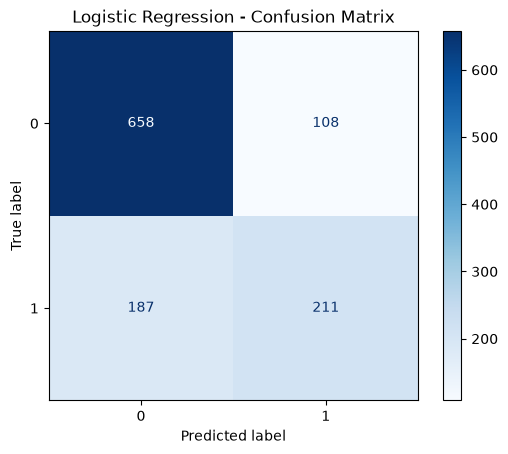

In [106]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [107]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [108]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [109]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.6503436426116839
Precision: 0.4884910485933504
Recall   : 0.4798994974874372
F1 Score : 0.4841571609632446
ROC AUC  : 0.609401445871656

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       766
           1       0.49      0.48      0.48       398

    accuracy                           0.65      1164
   macro avg       0.61      0.61      0.61      1164
weighted avg       0.65      0.65      0.65      1164


Confusion Matrix
[[566 200]
 [207 191]]


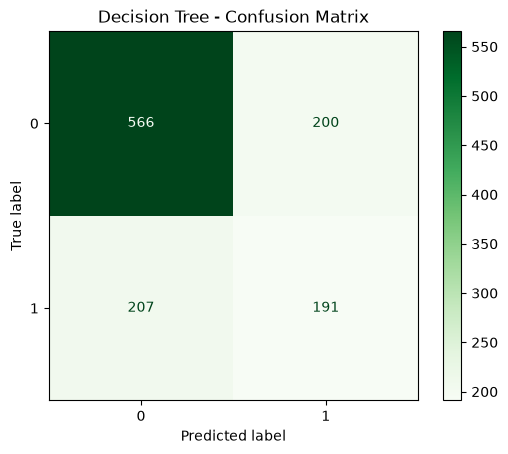

In [110]:
ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [111]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [112]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [113]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.7517182130584192
Precision: 0.7072243346007605
Recall   : 0.46733668341708545
F1 Score : 0.5627836611195158
ROC AUC  : 0.8043021898001759

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.90      0.83       766
           1       0.71      0.47      0.56       398

    accuracy                           0.75      1164
   macro avg       0.74      0.68      0.69      1164
weighted avg       0.75      0.75      0.74      1164


Confusion Matrix
[[689  77]
 [212 186]]


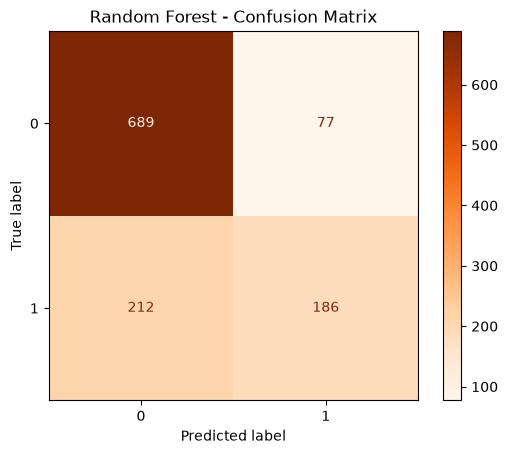

In [114]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [116]:
import xgboost

print(xgboost.__version__)

3.3.0


In [117]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [118]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [119]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.7396907216494846
Precision: 0.6507936507936508
Recall   : 0.5150753768844221
F1 Score : 0.5750350631136045
ROC AUC  : 0.7880098928060669

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       766
           1       0.65      0.52      0.58       398

    accuracy                           0.74      1164
   macro avg       0.71      0.69      0.69      1164
weighted avg       0.73      0.74      0.73      1164


Confusion Matrix
[[656 110]
 [193 205]]


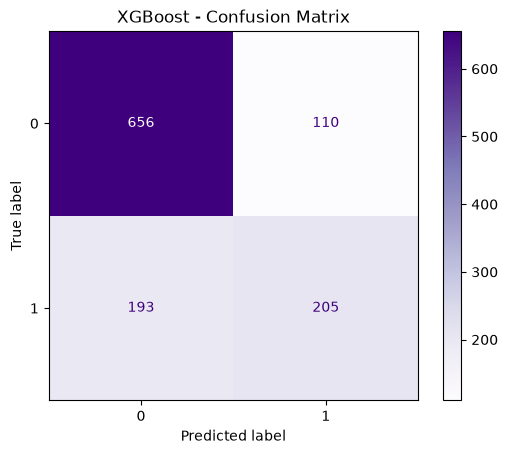

In [120]:
ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    cmap="Purples"
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [121]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [122]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [123]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

In [124]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.A

In [125]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Cross Validation Accuracy:
0.755047064666274


In [126]:
best_rf = random_search.best_estimator_

In [127]:
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best))

print("\nClassification Report")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_best))

Accuracy : 0.7637457044673539
Precision: 0.7489878542510121
Recall   : 0.4648241206030151
F1 Score : 0.5736434108527132
ROC AUC  : 0.7992147421179003

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       766
           1       0.75      0.46      0.57       398

    accuracy                           0.76      1164
   macro avg       0.76      0.69      0.71      1164
weighted avg       0.76      0.76      0.75      1164


Confusion Matrix
[[704  62]
 [213 185]]


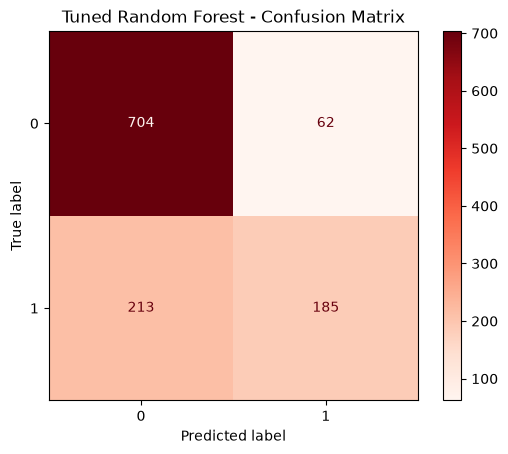

In [128]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="Reds"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15
feature_importance.head(15)

,Feature,Importance
6,rating,0.110592
13,ico_duration_days,0.105282
7,teamsize,0.082937
0,price_usd,0.077412
12,ico_end_month,0.073388
2,token_for_sale,0.069937
1,distributed_in_ico,0.062332
10,ico_start_month,0.060339
11,ico_end_year,0.055951
9,ico_start_year,0.051831


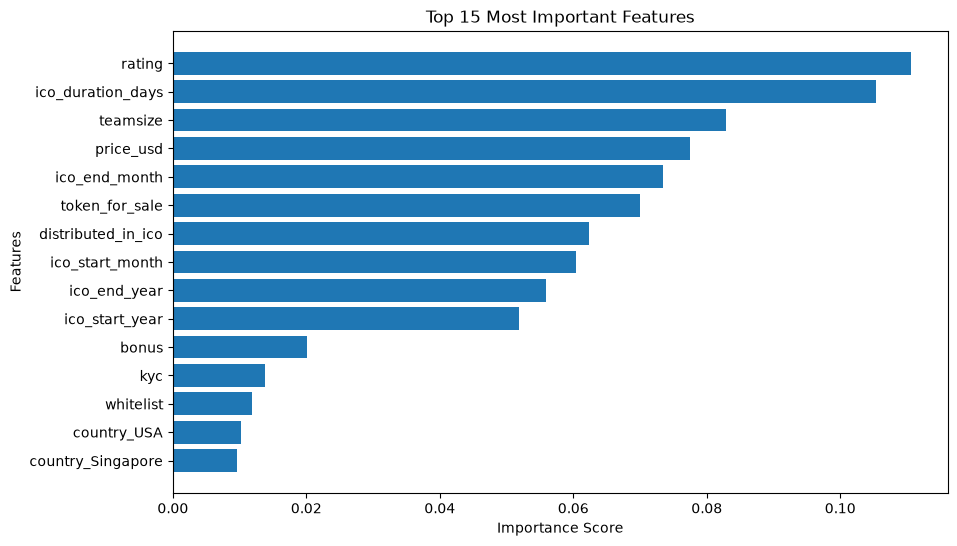

In [130]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(15),
    feature_importance["Importance"].head(15)
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [136]:
import joblib

joblib.dump(best_rf, "../models/ico_success_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_names.pkl")

['../models/feature_names.pkl']

In [137]:
import os

print(os.listdir())

['01_data_exploration.ipynb']
